Adriana Cruz xdxd

In [7]:
# Ejecuta esto solo una vez
import subprocess
subprocess.run(["pip", "install", "psycopg2-binary", "sqlalchemy", "pandas", "matplotlib", "seaborn"], check=True)

CompletedProcess(args=['pip', 'install', 'psycopg2-binary', 'sqlalchemy', 'pandas', 'matplotlib', 'seaborn'], returncode=0)

In [10]:
from sqlalchemy import create_engine, text
import pandas as pd

#  Cambia 'tu_contraseña' por tu contraseña de PostgreSQL
DB_USER     = "postgres"
DB_PASSWORD = "123456"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "DW_Ventas"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Verificar conexión
with engine.connect() as conn:
    resultado = conn.execute(text("SELECT version()"))
    print("✅ Conexión exitosa:", resultado.fetchone()[0])

✅ Conexión exitosa: PostgreSQL 16.2, compiled by Visual C++ build 1937, 64-bit


In [11]:
sql_crear_tablas = """
-- =============================================
-- TABLAS DE DIMENSIÓN
-- =============================================

CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo     SERIAL PRIMARY KEY,
    fecha         DATE NOT NULL,
    anio          INTEGER,
    mes           INTEGER,
    trimestre     INTEGER,
    nombre_mes    VARCHAR(20),
    dia_semana    VARCHAR(15)
);

CREATE TABLE IF NOT EXISTS dim_producto (
    id_producto   SERIAL PRIMARY KEY,
    nombre        VARCHAR(100) NOT NULL,
    categoria     VARCHAR(50),
    subcategoria  VARCHAR(50),
    precio_unitario NUMERIC(10,2)
);

CREATE TABLE IF NOT EXISTS dim_cliente (
    id_cliente    SERIAL PRIMARY KEY,
    nombre        VARCHAR(100) NOT NULL,
    ciudad        VARCHAR(50),
    estado        VARCHAR(50),
    region        VARCHAR(30)
);

CREATE TABLE IF NOT EXISTS dim_vendedor (
    id_vendedor   SERIAL PRIMARY KEY,
    nombre        VARCHAR(100) NOT NULL,
    zona          VARCHAR(50),
    sucursal      VARCHAR(50)
);

-- =============================================
-- TABLA DE HECHOS
-- =============================================

CREATE TABLE IF NOT EXISTS fact_ventas (
    id_venta      SERIAL PRIMARY KEY,
    id_tiempo     INTEGER REFERENCES dim_tiempo(id_tiempo),
    id_producto   INTEGER REFERENCES dim_producto(id_producto),
    id_cliente    INTEGER REFERENCES dim_cliente(id_cliente),
    id_vendedor   INTEGER REFERENCES dim_vendedor(id_vendedor),
    cantidad      INTEGER,
    precio_venta  NUMERIC(10,2),
    descuento     NUMERIC(5,2),
    total_venta   NUMERIC(10,2)
);
"""

with engine.connect() as conn:
    conn.execute(text(sql_crear_tablas))
    conn.commit()
    print("✅ Tablas creadas correctamente")

✅ Tablas creadas correctamente


In [12]:
import pandas as pd
import numpy as np
from datetime import date, timedelta
import random

random.seed(42)
np.random.seed(42)

# ---------- dim_tiempo ----------
fechas = [date(2023, 1, 1) + timedelta(days=i) for i in range(365)]
meses_es = {1:"Enero",2:"Febrero",3:"Marzo",4:"Abril",5:"Mayo",6:"Junio",
            7:"Julio",8:"Agosto",9:"Septiembre",10:"Octubre",11:"Noviembre",12:"Diciembre"}
dias_es   = {0:"Lunes",1:"Martes",2:"Miércoles",3:"Jueves",4:"Viernes",5:"Sábado",6:"Domingo"}

df_tiempo = pd.DataFrame({
    "fecha":       fechas,
    "anio":        [f.year for f in fechas],
    "mes":         [f.month for f in fechas],
    "trimestre":   [(f.month - 1) // 3 + 1 for f in fechas],
    "nombre_mes":  [meses_es[f.month] for f in fechas],
    "dia_semana":  [dias_es[f.weekday()] for f in fechas]
})

# ---------- dim_producto ----------
productos = [
    ("Laptop HP",       "Electrónica",  "Computadoras",  12500),
    ("Mouse Inalámbrico","Electrónica", "Accesorios",      350),
    ("Teclado Mecánico","Electrónica",  "Accesorios",      850),
    ("Monitor 24\"",    "Electrónica",  "Pantallas",      4200),
    ("Silla Ergonómica","Mobiliario",   "Sillas",         3800),
    ("Escritorio",      "Mobiliario",   "Mesas",          2200),
    ("Impresora",       "Electrónica",  "Impresión",      1800),
    ("Auriculares",     "Electrónica",  "Audio",           650),
    ("Webcam HD",       "Electrónica",  "Accesorios",      980),
    ("Tablet",          "Electrónica",  "Móviles",        5500),
]
df_producto = pd.DataFrame(productos, columns=["nombre","categoria","subcategoria","precio_unitario"])

# ---------- dim_cliente ----------
ciudades = [("Xalapa","Veracruz","Sur"),("CDMX","CDMX","Centro"),
            ("Monterrey","NL","Norte"),("Puebla","Puebla","Centro"),
            ("Guadalajara","Jalisco","Occidente"),("Veracruz","Veracruz","Sur"),
            ("Mérida","Yucatán","Sureste"),("Tijuana","BC","Norte"),
            ("León","Guanajuato","Centro"),("Oaxaca","Oaxaca","Sur")]
nombres_c = ["Ana Torres","Luis Pérez","María García","Carlos López","Sandra Ruiz",
             "Jorge Méndez","Patricia Soto","Roberto Cruz","Elena Vargas","Miguel Ángel Flores"]
df_cliente = pd.DataFrame({
    "nombre":  nombres_c,
    "ciudad":  [c[0] for c in ciudades],
    "estado":  [c[1] for c in ciudades],
    "region":  [c[2] for c in ciudades]
})

# ---------- dim_vendedor ----------
df_vendedor = pd.DataFrame({
    "nombre":   ["Pedro Ramírez","Sofía Hernández","Andrés Castillo","Lucía Moreno","Diego Núñez"],
    "zona":     ["Sur","Centro","Norte","Occidente","Sureste"],
    "sucursal": ["Xalapa","CDMX","Monterrey","Guadalajara","Mérida"]
})

# ---------- Cargar dimensiones ----------
df_tiempo.to_sql("dim_tiempo",   engine, if_exists="append", index=False)
df_producto.to_sql("dim_producto", engine, if_exists="append", index=False)
df_cliente.to_sql("dim_cliente",  engine, if_exists="append", index=False)
df_vendedor.to_sql("dim_vendedor", engine, if_exists="append", index=False)
print("✅ Dimensiones cargadas")

# ---------- fact_ventas (500 registros) ----------
n = 500
id_tiempos   = list(range(1, len(df_tiempo)   + 1))
id_productos = list(range(1, len(df_producto) + 1))
id_clientes  = list(range(1, len(df_cliente)  + 1))
id_vendedores= list(range(1, len(df_vendedor) + 1))

cantidades    = np.random.randint(1, 10, n)
precios_idx   = np.random.choice(id_productos, n) - 1
precios_venta = [float(df_producto.iloc[i]["precio_unitario"]) for i in precios_idx]
descuentos    = np.round(np.random.uniform(0, 0.15, n), 2)
totales       = [round(cantidades[i] * precios_venta[i] * (1 - descuentos[i]), 2) for i in range(n)]

df_ventas = pd.DataFrame({
    "id_tiempo":   np.random.choice(id_tiempos, n),
    "id_producto": precios_idx + 1,
    "id_cliente":  np.random.choice(id_clientes, n),
    "id_vendedor": np.random.choice(id_vendedores, n),
    "cantidad":    cantidades,
    "precio_venta":precios_venta,
    "descuento":   descuentos,
    "total_venta": totales
})

df_ventas.to_sql("fact_ventas", engine, if_exists="append", index=False)
print(f"✅ {n} registros de ventas cargados en fact_ventas")

✅ Dimensiones cargadas
✅ 500 registros de ventas cargados en fact_ventas


In [13]:
# Ventas totales por región
query_region = """
    SELECT c.region,
           COUNT(*)            AS num_ventas,
           SUM(f.total_venta)  AS total
    FROM fact_ventas f
    JOIN dim_cliente c ON f.id_cliente = c.id_cliente
    GROUP BY c.region
    ORDER BY total DESC;
"""
df_region = pd.read_sql(query_region, engine)
print("📍 Ventas por Región:\n", df_region)

# Productos más vendidos
query_prod = """
    SELECT p.nombre,
           SUM(f.cantidad)     AS unidades_vendidas,
           SUM(f.total_venta)  AS ingreso_total
    FROM fact_ventas f
    JOIN dim_producto p ON f.id_producto = p.id_producto
    GROUP BY p.nombre
    ORDER BY unidades_vendidas DESC
    LIMIT 5;
"""
df_productos_top = pd.read_sql(query_prod, engine)
print("\n🏆 Top 5 Productos:\n", df_productos_top)

# Ventas por trimestre
query_trim = """
    SELECT t.trimestre,
           t.anio,
           SUM(f.total_venta) AS total
    FROM fact_ventas f
    JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
    GROUP BY t.trimestre, t.anio
    ORDER BY t.anio, t.trimestre;
"""
df_trimestre = pd.read_sql(query_trim, engine)
print("\n📅 Ventas por Trimestre:\n", df_trimestre)

# Rendimiento por vendedor
query_vend = """
    SELECT v.nombre,
           COUNT(*)           AS ventas_realizadas,
           SUM(f.total_venta) AS total_generado
    FROM fact_ventas f
    JOIN dim_vendedor v ON f.id_vendedor = v.id_vendedor
    GROUP BY v.nombre
    ORDER BY total_generado DESC;
"""
df_vendedores_res = pd.read_sql(query_vend, engine)
print("\n👤 Rendimiento Vendedores:\n", df_vendedores_res)

📍 Ventas por Región:
       region  num_ventas      total
0     Centro         150  2748375.3
1        Sur         144  2210002.4
2      Norte          97  1732475.6
3  Occidente          62   856252.3
4    Sureste          47   621914.8

🏆 Top 5 Productos:
              nombre  unidades_vendidas  ingreso_total
0         Laptop HP                303      3536125.0
1  Silla Ergonómica                282       986822.0
2        Escritorio                275       559856.0
3  Teclado Mecánico                263       205606.5
4            Tablet                260      1302455.0

📅 Ventas por Trimestre:
    trimestre  anio      total
0          1  2023  1798871.9
1          2  2023  2517809.9
2          3  2023  1476807.4
3          4  2023  2375531.2

👤 Rendimiento Vendedores:
             nombre  ventas_realizadas  total_generado
0     Lucía Moreno                110       1968040.4
1      Diego Núñez                100       1659448.0
2  Andrés Castillo                112       1658273

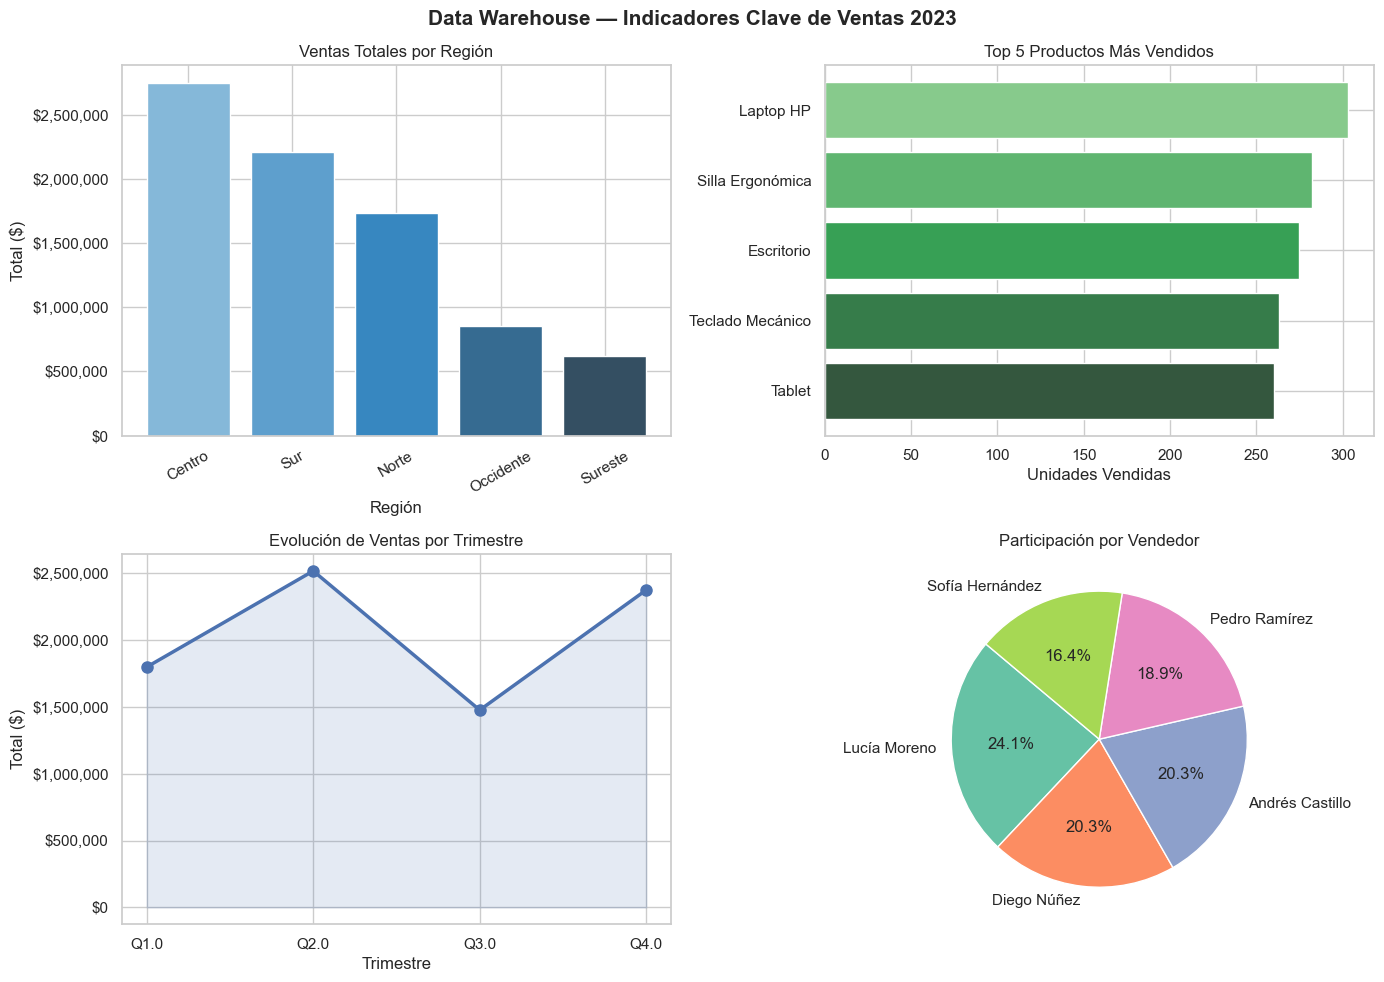

✅ Gráficas generadas y guardadas como 'indicadores_DW.png'


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Data Warehouse — Indicadores Clave de Ventas 2023", fontsize=15, fontweight="bold")

# --- Gráfica 1: Ventas por región (barras) ---
ax1 = axes[0, 0]
ax1.bar(df_region["region"], df_region["total"], color=sns.color_palette("Blues_d", len(df_region)))
ax1.set_title("Ventas Totales por Región")
ax1.set_xlabel("Región")
ax1.set_ylabel("Total ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.tick_params(axis="x", rotation=30)

# --- Gráfica 2: Top productos (barras horizontales) ---
ax2 = axes[0, 1]
ax2.barh(df_productos_top["nombre"], df_productos_top["unidades_vendidas"],
         color=sns.color_palette("Greens_d", len(df_productos_top)))
ax2.set_title("Top 5 Productos Más Vendidos")
ax2.set_xlabel("Unidades Vendidas")
ax2.invert_yaxis()

# --- Gráfica 3: Ventas por trimestre (línea) ---
ax3 = axes[1, 0]
etiquetas = [f"Q{row.trimestre}" for _, row in df_trimestre.iterrows()]
ax3.plot(etiquetas, df_trimestre["total"], marker="o", linewidth=2.5,
         color="#4C72B0", markersize=8)
ax3.fill_between(etiquetas, df_trimestre["total"], alpha=0.15, color="#4C72B0")
ax3.set_title("Evolución de Ventas por Trimestre")
ax3.set_xlabel("Trimestre")
ax3.set_ylabel("Total ($)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# --- Gráfica 4: Participación de vendedores (pastel) ---
ax4 = axes[1, 1]
ax4.pie(df_vendedores_res["total_generado"],
        labels=df_vendedores_res["nombre"],
        autopct="%1.1f%%",
        startangle=140,
        colors=sns.color_palette("Set2"))
ax4.set_title("Participación por Vendedor")

plt.tight_layout()
plt.savefig("indicadores_DW.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráficas generadas y guardadas como 'indicadores_DW.png'")


In [15]:
# Configuración global de estilo
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'figure.facecolor':   'white',
})
COLORES = ['#1E7BB0','#2ECC71','#E74C3C','#F39C12','#9B59B6','#1ABC9C']
print('Configuración de Matplotlib lista ✅')

Configuración de Matplotlib lista ✅


ETL (EXTRACCION, TRANSFORMACION Y CARGA)

##  Proceso ETL — Extracción, Transformación y Carga 
##El proceso ETL (Extract, Transform, Load) es el mecanismo central de un Data Warehouse.
##Permite tomar datos de múltiples fuentes, limpiarlos y cargarlos en un modelo dimensional.

### Fases:
| Fase | Descripción | Herramienta |
|------|-------------|-------------|
| **Extract** | Lectura de datos desde archivos CSV simulados | `pandas.read_csv()` |
| **Transform** | Validación, limpieza, normalización y cálculo de métricas | `pandas`, lógica Python |
| **Load** | Inserción en tablas de dimensión y hechos en PostgreSQL | `SQLAlchemy`, `to_sql()` |

> Cada fase está registrada con logs para rastrear errores y volumen de datos procesados.

In [ ]:
# =============================================================
# ETL - Data Warehouse DW_Ventas
# Materia: Extracción del Conocimiento de Base de Datos
# UTCV | Adriana Cruz Modesto
# =============================================================

import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from datetime import date, timedelta
import random
import logging

# ── Configurar logging para rastrear el proceso ETL ──────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger("ETL_DW")

log.info("✅ Librerías cargadas correctamente")

In [ ]:
# =============================================================
# FASE 1 — EXTRACT
# Simulamos archivos CSV como fuentes de datos operacionales.
# En un caso real, estos vendrían de sistemas ERP o CRM.
# =============================================================

log.info("═══ INICIANDO FASE EXTRACT ═══")

random.seed(42)
np.random.seed(42)

# ── 1.1 Generar CSV de productos ──────────────────────────────
productos_data = {
    "nombre":         ["Laptop HP","Mouse Inalámbrico","Teclado Mecánico",
                       "Monitor 24\"","Silla Ergonómica","Escritorio",
                       "Impresora","Auriculares","Webcam HD","Tablet"],
    "categoria":      ["Electrónica","Electrónica","Electrónica","Electrónica",
                       "Mobiliario","Mobiliario","Electrónica","Electrónica",
                       "Electrónica","Electrónica"],
    "subcategoria":   ["Computadoras","Accesorios","Accesorios","Pantallas",
                       "Sillas","Mesas","Impresión","Audio","Accesorios","Móviles"],
    "precio_unitario":[12500,350,850,4200,3800,2200,1800,650,980,5500]
}
df_productos_raw = pd.DataFrame(productos_data)
df_productos_raw.to_csv("productos.csv", index=False)
log.info(f"  [Extract] productos.csv → {len(df_productos_raw)} registros")

# ── 1.2 Generar CSV de clientes ───────────────────────────────
clientes_data = {
    "nombre": ["Ana Torres","Luis Pérez","María García","Carlos López",
               "Sandra Ruiz","Jorge Méndez","Patricia Soto","Roberto Cruz",
               "Elena Vargas","Miguel Ángel Flores"],
    "ciudad": ["Xalapa","CDMX","Monterrey","Puebla","Guadalajara",
               "Veracruz","Mérida","Tijuana","León","Oaxaca"],
    "estado": ["Veracruz","CDMX","NL","Puebla","Jalisco",
               "Veracruz","Yucatán","BC","Guanajuato","Oaxaca"],
    "region": ["Sur","Centro","Norte","Centro","Occidente",
               "Sur","Sureste","Norte","Centro","Sur"]
}
df_clientes_raw = pd.DataFrame(clientes_data)
df_clientes_raw.to_csv("clientes.csv", index=False)
log.info(f"  [Extract] clientes.csv → {len(df_clientes_raw)} registros")

# ── 1.3 Generar CSV de ventas ─────────────────────────────────
n = 500
fechas_rango = [date(2023, 1, 1) + timedelta(days=i) for i in range(365)]

ventas_data = {
    "fecha":        [str(random.choice(fechas_rango)) for _ in range(n)],
    "id_producto":  np.random.randint(1, 11, n),
    "id_cliente":   np.random.randint(1, 11, n),
    "id_vendedor":  np.random.randint(1, 6,  n),
    "cantidad":     np.random.randint(1, 10, n),
    "descuento":    np.round(np.random.uniform(0, 0.15, n), 2),
    # Introducir datos sucios intencionalmente para demostrar Transform
    "precio_venta": [None if i % 50 == 0 else
                     float(productos_data["precio_unitario"][(np.random.randint(0,10))])
                     for i in range(n)]
}
df_ventas_raw = pd.DataFrame(ventas_data)
df_ventas_raw.to_csv("ventas_raw.csv", index=False)
log.info(f"  [Extract] ventas_raw.csv → {len(df_ventas_raw)} registros")

# ── 1.4 Leer los CSV (simulando lectura de fuente externa) ────
df_ventas_raw    = pd.read_csv("ventas_raw.csv")
df_clientes_raw  = pd.read_csv("clientes.csv")
df_productos_raw = pd.read_csv("productos.csv")

log.info("✅ FASE EXTRACT completada")
print("\n📋 Vista previa de ventas_raw.csv:")
print(df_ventas_raw.head(3).to_string())
print(f"\n⚠️  Valores nulos detectados:\n{df_ventas_raw.isnull().sum()}")

In [ ]:
# =============================================================
# FASE 2 — TRANSFORM
# Aquí aplicamos las reglas de negocio, limpieza y enriquecimiento
# de datos antes de cargarlos al Data Warehouse.
# =============================================================

log.info("═══ INICIANDO FASE TRANSFORM ═══")

# ── 2.1 Validar y corregir tipos de datos ─────────────────────
log.info("  [Transform] Validando tipos de datos...")

df_ventas = df_ventas_raw.copy()
df_ventas["fecha"]       = pd.to_datetime(df_ventas["fecha"])
df_ventas["cantidad"]    = df_ventas["cantidad"].astype(int)
df_ventas["descuento"]   = df_ventas["descuento"].astype(float)
df_ventas["id_producto"] = df_ventas["id_producto"].astype(int)
df_ventas["id_cliente"]  = df_ventas["id_cliente"].astype(int)
df_ventas["id_vendedor"] = df_ventas["id_vendedor"].astype(int)

# ── 2.2 Tratar valores nulos ──────────────────────────────────
log.info("  [Transform] Tratando valores nulos...")

nulos_antes = df_ventas["precio_venta"].isnull().sum()

# Estrategia: rellenar con el precio del catálogo de productos
precio_catalogo = dict(zip(
    range(1, len(df_productos_raw)+1),
    df_productos_raw["precio_unitario"]
))
df_ventas["precio_venta"] = df_ventas.apply(
    lambda row: precio_catalogo.get(row["id_producto"], 0)
    if pd.isnull(row["precio_venta"]) else row["precio_venta"],
    axis=1
)
nulos_despues = df_ventas["precio_venta"].isnull().sum()
log.info(f"  [Transform] Nulos precio_venta: {nulos_antes} → {nulos_despues}")

# ── 2.3 Eliminar duplicados ───────────────────────────────────
log.info("  [Transform] Verificando duplicados...")
dupes = df_ventas.duplicated().sum()
df_ventas = df_ventas.drop_duplicates()
log.info(f"  [Transform] Duplicados eliminados: {dupes}")

# ── 2.4 Calcular métrica de negocio: total_venta ──────────────
log.info("  [Transform] Calculando total_venta...")

# Regla de negocio: total = cantidad × precio × (1 − descuento)
df_ventas["total_venta"] = (
    df_ventas["cantidad"] *
    df_ventas["precio_venta"] *
    (1 - df_ventas["descuento"])
).round(2)

# ── 2.5 Construir dimensión de tiempo desde fechas ────────────
log.info("  [Transform] Construyendo dim_tiempo...")

meses_es = {1:"Enero",2:"Febrero",3:"Marzo",4:"Abril",5:"Mayo",6:"Junio",
            7:"Julio",8:"Agosto",9:"Septiembre",10:"Octubre",11:"Noviembre",12:"Diciembre"}
dias_es  = {0:"Lunes",1:"Martes",2:"Miércoles",3:"Jueves",
            4:"Viernes",5:"Sábado",6:"Domingo"}

fechas_unicas = sorted(df_ventas["fecha"].unique())
df_tiempo_transform = pd.DataFrame({
    "fecha":      [pd.Timestamp(f).date() for f in fechas_unicas],
    "anio":       [pd.Timestamp(f).year for f in fechas_unicas],
    "mes":        [pd.Timestamp(f).month for f in fechas_unicas],
    "trimestre":  [(pd.Timestamp(f).month - 1) // 3 + 1 for f in fechas_unicas],
    "nombre_mes": [meses_es[pd.Timestamp(f).month] for f in fechas_unicas],
    "dia_semana": [dias_es[pd.Timestamp(f).weekday()] for f in fechas_unicas]
})

# ── 2.6 Limpiar texto en dimensiones ─────────────────────────
log.info("  [Transform] Normalizando texto en dimensiones...")

df_clientes  = df_clientes_raw.copy()
df_productos = df_productos_raw.copy()

for col in df_clientes.select_dtypes(include="object").columns:
    df_clientes[col] = df_clientes[col].str.strip().str.title()

for col in df_productos.select_dtypes(include="object").columns:
    df_productos[col] = df_productos[col].str.strip()

df_vendedores = pd.DataFrame({
    "nombre":   ["Pedro Ramírez","Sofía Hernández","Andrés Castillo","Lucía Moreno","Diego Núñez"],
    "zona":     ["Sur","Centro","Norte","Occidente","Sureste"],
    "sucursal": ["Xalapa","CDMX","Monterrey","Guadalajara","Mérida"]
})

log.info("✅ FASE TRANSFORM completada")

# ── Resumen de transformación ─────────────────────────────────
print("\n📊 Resumen de transformación:")
print(f"  • Registros de ventas procesados : {len(df_ventas)}")
print(f"  • Registros de tiempo generados  : {len(df_tiempo_transform)}")
print(f"  • Nulos corregidos               : {nulos_antes}")
print(f"  • Duplicados eliminados          : {dupes}")
print(f"  • Nueva columna calculada        : total_venta")
print(f"\n  Rango de fechas: {df_tiempo_transform['fecha'].min()} → {df_tiempo_transform['fecha'].max()}")
print(f"  total_venta — min: ${df_ventas['total_venta'].min():,.2f} | max: ${df_ventas['total_venta'].max():,.2f}")

In [ ]:
# =============================================================
# FASE 3 — LOAD
# Cargamos los datos transformados al Data Warehouse en PostgreSQL
# usando SQLAlchemy. La función load_tabla() registra cada paso.
# =============================================================

log.info("═══ INICIANDO FASE LOAD ═══")

# ── Conexión al DW ────────────────────────────────────────────
DB_USER     = "postgres"
DB_PASSWORD = "tu_contraseña"   # ← cambia esto
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "DW_Ventas"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# ── Función reutilizable de carga con log ─────────────────────
def load_tabla(df, nombre_tabla, engine, if_exists="append"):
    """
    Carga un DataFrame a una tabla de PostgreSQL.
    Registra en el log el resultado de la operación.
    """
    try:
        df.to_sql(nombre_tabla, engine, if_exists=if_exists, index=False)
        log.info(f"  [Load] {nombre_tabla:25s} → {len(df):>5} filas insertadas ✅")
        return len(df)
    except Exception as e:
        log.error(f"  [Load] ERROR en {nombre_tabla}: {e}")
        return 0

# ── Verificar si ya hay datos (evitar duplicados en re-ejecución) ──
with engine.connect() as conn:
    hay_datos = conn.execute(text("SELECT COUNT(*) FROM dim_tiempo")).scalar()

if hay_datos > 0:
    log.warning("  Las tablas ya contienen datos. Limpiando antes de recargar...")
    with engine.connect() as conn:
        conn.execute(text("TRUNCATE TABLE fact_ventas, dim_tiempo, dim_producto, dim_cliente, dim_vendedor RESTART IDENTITY CASCADE"))
        conn.commit()
    log.info("  Tablas limpiadas correctamente")

# ── Cargar dimensiones primero (por integridad referencial) ───
total_filas = 0
total_filas += load_tabla(df_tiempo_transform, "dim_tiempo",   engine)
total_filas += load_tabla(df_productos,        "dim_producto",  engine)
total_filas += load_tabla(df_clientes,         "dim_cliente",   engine)
total_filas += load_tabla(df_vendedores,       "dim_vendedor",  engine)

# ── Mapear fechas a id_tiempo antes de cargar hechos ──────────
log.info("  [Load] Preparando claves foráneas de fact_ventas...")

with engine.connect() as conn:
    df_tiempo_ids = pd.read_sql("SELECT id_tiempo, fecha FROM dim_tiempo", conn)

df_tiempo_ids["fecha"] = pd.to_datetime(df_tiempo_ids["fecha"])
df_ventas["fecha"]     = pd.to_datetime(df_ventas["fecha"])
df_ventas_final = df_ventas.merge(df_tiempo_ids, on="fecha", how="left")

df_fact = df_ventas_final[[
    "id_tiempo","id_producto","id_cliente","id_vendedor",
    "cantidad","precio_venta","descuento","total_venta"
]]

# ── Cargar tabla de hechos ────────────────────────────────────
total_filas += load_tabla(df_fact, "fact_ventas", engine)

log.info(f"✅ FASE LOAD completada — Total de filas cargadas: {total_filas}")